<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Custom embedddings con Gensim



### Consigna del desafío 2

- Crear sus propios vectores con Gensim basado en lo visto en clase con otro artista del dataset Songs.
- Elegir términos de interés y buscar términos más similares y menos similares.
- Realizar una reduccion de dimensionalidad a los embeddings, llevándolos a 2 dimensiones. Graficar los embeddings proyectados y seleccionar una cantidad de términos (variable MAX_WORDS) de forma tal que la visualización sea adecuada.
- Inspeccionar el grafico y buscar pequeños grupos de palabras que puedan formarse. Interpretarlos e intentar obtener conclusiones. En lo posible, acompañar los grupos de palabras con capturas (y pegarlas en celdas de texto)

In [1]:
import pandas as pd
import zipfile

from gensim.models import Word2Vec

### Datos
Se utilza como dataset las canciones de Rihanna, donde cada linea representa un documento.

In [7]:
output_zip = "../datasets/songs_dataset.zip"
extract_dir = "./"
with zipfile.ZipFile(output_zip, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

df = pd.read_csv("songs_dataset/rihanna.txt", sep="/n", header=None, engine="python")
df.head()

,0
0,Ghost in the mirror
1,"I knew your face once, but now it's unclear"
2,And I can't feel my body now
3,I'm separate from here and now A drug and a dream
4,"We lost connection, oh come back to me"


In [8]:
print("Cantidad de documentos:", df.shape[0])

Cantidad de documentos: 3895


### 1 - Preprocesamiento

Se convierte cada linea/documento en una secuencia de palabras

In [65]:
from tensorflow.keras.preprocessing.text import text_to_word_sequence

sentence_tokens = []
for _, row in df.iterrows():
    sentence_tokens.append(text_to_word_sequence(row[0]))

In [66]:
sentence_tokens[:2]

[['ghost', 'in', 'the', 'mirror'],
 ['i', 'knew', 'your', 'face', 'once', 'but', 'now', "it's", 'unclear']]

### 2 - Crear los vectores (word2vec)

Generación del vocabulario utilizando la estrucura Skip-gram. Esta estructura se basa en la idea de predecir el contexto a partir de una palabra dada.

In [67]:
from gensim.models.callbacks import CallbackAny2Vec


# Durante el entrenamiento gensim por defecto no informa el "loss" en cada época
# Sobrecargamos el callback para poder tener esta información
class Callback(CallbackAny2Vec):
    """Callback to print loss after each epoch"""

    def __init__(self):
        self.epoch = 0

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.epoch == 0:
            print("Loss after epoch {}: {}".format(self.epoch, loss))
        else:
            print(
                "Loss after epoch {}: {}".format(
                    self.epoch, loss - self.loss_previous_step
                )
            )
        self.epoch += 1
        self.loss_previous_step = loss

In [ ]:
# Crearmos el modelo generador de vectores
# En este caso utilizaremos la estructura modelo Skipgram
w2v_model = Word2Vec(
    min_count=5,  # frecuencia mínima de palabra para incluirla en el vocabulario
    window=2,  # cant de palabras antes y desp de la predicha
    vector_size=300,  # dimensionalidad de los vectores
    negative=20,  # cantidad de negative samples... 0 es no se usa
    workers=1,  # si tienen más cores pueden cambiar este valor
    sg=1,  # modelo 0:CBOW  1:skipgram
)


# Obtener el vocabulario con los tokens
w2v_model.build_vocab(sentence_tokens)

In [69]:
print("Cantidad de docs en el corpus:", w2v_model.corpus_count)

print("Cantidad de words distintas en el corpus:", len(w2v_model.wv.index_to_key))

Cantidad de docs en el corpus: 3895
Cantidad de words distintas en el corpus: 660


### 3 - Entrenar embeddings

In [70]:
# Entrenamos el modelo generador de vectores
w2v_model.train(
    sentence_tokens,
    total_examples=w2v_model.corpus_count,
    epochs=80,
    compute_loss=True,
    callbacks=[Callback()],
)

Loss after epoch 0: 213381.40625
Loss after epoch 1: 148119.34375
Loss after epoch 2: 144840.5625
Loss after epoch 3: 144403.5
Loss after epoch 4: 135036.5
Loss after epoch 5: 129777.1875
Loss after epoch 6: 122893.25
Loss after epoch 7: 107391.75
Loss after epoch 8: 102886.0
Loss after epoch 9: 99990.625
Loss after epoch 10: 97568.25
Loss after epoch 11: 93042.375
Loss after epoch 12: 92724.875
Loss after epoch 13: 90485.375
Loss after epoch 14: 87950.375
Loss after epoch 15: 86459.875
Loss after epoch 16: 85722.625
Loss after epoch 17: 85535.875
Loss after epoch 18: 81463.25
Loss after epoch 19: 79176.75
Loss after epoch 20: 78594.25
Loss after epoch 21: 77810.0
Loss after epoch 22: 78050.25
Loss after epoch 23: 76954.5
Loss after epoch 24: 77419.5
Loss after epoch 25: 76782.25
Loss after epoch 26: 76579.5
Loss after epoch 27: 75657.5
Loss after epoch 28: 76553.5
Loss after epoch 29: 76273.0
Loss after epoch 30: 75477.25
Loss after epoch 31: 75703.5
Loss after epoch 32: 76012.5
Loss 

(1429446, 2414320)

Si bien la perdida baja, a partir de la epoca 60, aproximadamente, la perdida se estabiliza.

### 4 - Ensayar

In [108]:
print("Palabras más similares a 'love':")
w2v_model.wv.most_similar(positive=["love"], topn=10)

Palabras más similares a 'love':


[('ahhh', 0.5658285617828369),
 ('verse', 0.5251782536506653),
 ('hopeless', 0.4840248227119446),
 ('granted', 0.4757678210735321),
 ('mine', 0.4408048987388611),
 ('smell', 0.43883055448532104),
 ('happened', 0.4365386664867401),
 ('used', 0.4302714765071869),
 ('am', 0.4254346787929535),
 ('place', 0.42347487807273865)]

In [78]:
print("Palabras menos similares a 'girl':")
w2v_model.wv.most_similar(negative=["girl"], topn=10)

Palabras menos similares a 'girl':


[('e', -0.04488886520266533),
 ('push', -0.04886694625020027),
 ('wish', -0.052356742322444916),
 ('finally', -0.05643487349152565),
 ('over', -0.06185311824083328),
 ('v', -0.06258725374937057),
 ('stress', -0.06388260424137115),
 ('if', -0.06731932610273361),
 ('try', -0.06746469438076019),
 ('hey', -0.0691971629858017)]

In [99]:
print("Palabras más similares a 'home':")
w2v_model.wv.most_similar(positive=["away"], topn=10)

Palabras más similares a 'home':


[('fading', 0.6247615814208984),
 ('gets', 0.5720945596694946),
 ("'til", 0.48764768242836),
 ('stress', 0.46312522888183594),
 ("tryin'", 0.4506320357322693),
 ('sometimes', 0.44802752137184143),
 ('everybody', 0.4312899708747864),
 ('running', 0.4296473264694214),
 ('push', 0.4277888536453247),
 ("let's", 0.4233621060848236)]

In [80]:
print("Palabras más similares a 'beautiful':")
w2v_model.wv.most_similar(positive=["beautiful"], topn=10)

Palabras más similares a 'beautiful':


[('diamonds', 0.7048359513282776),
 ('stress', 0.6946671605110168),
 ('people', 0.6370070576667786),
 ('shining', 0.6107486486434937),
 ('diamond', 0.6082154512405396),
 ('sky', 0.599918782711029),
 ('rise', 0.587763249874115),
 ('shine', 0.5846264958381653),
 ('mistakes', 0.5748342275619507),
 ('yes', 0.5736372470855713)]

In [81]:
print("Palabras menos similares a 'heart':")
w2v_model.wv.most_similar(negative=["heart"], topn=10)

Palabras menos similares a 'heart':


[("ain't", 0.0037272346671670675),
 ('said', 0.002963023027405143),
 ('takes', -0.006235101725906134),
 ('means', -0.019623393192887306),
 ('gonna', -0.02761896327137947),
 ('finally', -0.0467829704284668),
 ('oh', -0.04756913706660271),
 ('chance', -0.05077055096626282),
 ('behind', -0.054955411702394485),
 ('will', -0.056842245161533356)]

Para los casos positivos, la palabra que mas destaca, considerando la similitud, es "beautiful" que se relaciona con palabras como "diamonds", "shining" o "people". Tambien existe una relación coherente entre "away" y "fading", pero para "love" la relación con "ahhh/verse" no es tan clara lo cual puede indicar que se esta considerando las palabras con mayor ocurrencia en su ventana de contexto mas que en su significado.

En el caso de las palabras ("heart", "girl") con menos similitud, los valores son cercanos a ceros. Por lo cual estas palabras aparecen en distintos contextos y no se relacionan entre sí.

### 5 - Visualizar agrupación de vectores

Se reduce la dimensionalidad de los embeddings a 2 dimensiones usando t-SNE.

In [101]:
from sklearn.manifold import TSNE
import numpy as np


def reduce_dimensions(model, num_dimensions=2):
    vectors = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)

    tsne = TSNE(n_components=num_dimensions, random_state=0)
    vectors = tsne.fit_transform(vectors)

    return vectors, labels

In [106]:
import plotly.express as px

vecs, labels = reduce_dimensions(w2v_model)

MAX_WORDS = 200
fig = px.scatter(
    x=vecs[:MAX_WORDS, 0], y=vecs[:MAX_WORDS, 1], text=labels[:MAX_WORDS]
)  # Graficar los embedddings en 2D
fig.show()

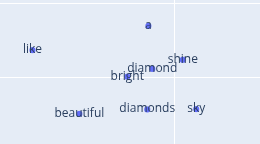
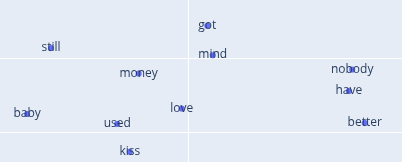
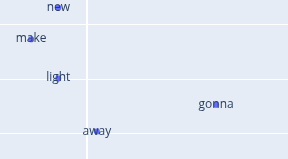
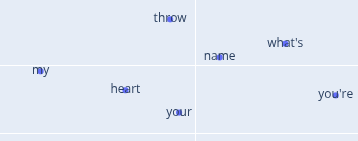

📝 Observaciones:
- Analizando el gráfico 2D, vemos que la palabra "beautiful" se relaciona, en su mayoria, con las mismas palabras que las del punto anterior. Esto era de esperar ya que los valores de similitud eran altos. Las otras palabras, "love" y "away", difieren un poco mas pero las palabras cercanas tienen sentido.
- Mirando las palabras cercanas a "heart", como "your/my/name" estan relacionadas a palabras de tipo posesivo.
- Podemos inferir que el gráfico muestra relaciones relaciones bastantes coherentes que condicen con lo visto en el punto anterior.
- A pesar de mostrar relaciones con sentido, se debe considerar la perdida en el entrenamiento. Que como se vio, tiende a un valor y que por mas que se aumenten las epocas, no pareciera mejorar.
- Otro factor que puede influir en los valores de similitud, es el tamaño del vocabulario. Siendo este de 660 palabras y con un corpus de 3895 documentos, es posible que muchas palabras aparecen muy pocas veces.
